<a href="https://colab.research.google.com/github/BrunoCapron/ESQ724-fundamentos_aprendizado_maquina/blob/main/Otimizacao_Hiperparametros/exemplo_optuna_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exemplo de uso de Optuna para otimização de hiperparâmetros

In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 23.1 MB/s eta 0:00:00


Consideramos novamente o problema de predição do valor de casas na California, usando uma versão simplificada do conjunto de dados imobiliários sobre distritos da California. Neste conjunto, só há atributos numéricos e não tem dados faltantes.

Carregamos o conjunto de dados e criamos os conjuntos de dados de treinamento, e teste:

In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(
housing.data, housing.target)

scaler = StandardScaler() #os dados são padronizados
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Criamos a função objetivo usada pelo Optuna

In [4]:
import optuna
import tensorflow as tf
from tensorflow import keras
import numpy as np

def objective(trial):

  #sugestão do espaço de hiperparâmetros
  learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True) #busca em escala logaritmica em vez de linear
  n_layers = trial.suggest_int("n_layers", 1, 3)
  activation = trial.suggest_categorical("activation", ["relu", "elu"])

  #inicializa o K-Fold
  kf = KFold(n_splits = 3, shuffle=True, random_state=42)
  fold_mae_scores = []

  #Itera sobre o folds
  for train_index,val_index in kf.split(X_train_scaled):
    #separa os dados de treino e validação para o fold atual
    X_fold_train, X_fold_val = X_train_scaled[train_index], X_train_scaled[val_index]
    y_fold_train, y_fold_val = y_train[train_index], y_train[val_index]

    #Criamos o modelo
    model = keras.models.Sequential()

    for i in range(n_layers):
      n_units = trial.suggest_categorical(f'n_units_l{i}',[32,64,128,256])
      model.add(keras.layers.Dense(n_units, activation=activation)) #camada escondidas
    model.add(keras.layers.Dense(1, activation='linear')) #camada de saída

    #Compilação
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='mse',
                  metrics=['mae'])

    #treinamento
    history = model.fit(X_fold_train, y_fold_train,
                        validation_data=(X_fold_val, y_fold_val),
                        epochs=20,
                        batch_size=32,
                        verbose=0)

  #armazena a melhor métrica de validação do fold
  best_val_mae = min(history.history['val_mae'])
  fold_mae_scores.append(best_val_mae)

  #média do MAE de validação de todos os folds
  mean_validation_mae = np.mean(fold_mae_scores)

  return mean_validation_mae



In [ ]:
#execução do estudo optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=300, show_progress_bar=True)

#resultados da otimização
print("--- Resultados da Otimização Optuna com K-Fold CV ---")
print(f"Número de Trials concluídas: {len(study.trials)}")
print(f"Melhor MAE de Validação (Média de 3 Folds): {study.best_value:.4f}")
print("Melhores Hiperparâmetros:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2025-11-20 22:44:52,059] A new study created in memory with name: no-name-efe65c9c-0ec2-4948-b025-0b48ba93b477


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2025-11-20 22:45:50,410] Trial 0 finished with value: 0.4274989068508148 and parameters: {'learning_rate': 0.0009355549520710712, 'n_layers': 1, 'activation': 'relu', 'n_units_l0': 32}. Best is trial 0 with value: 0.4274989068508148.
[I 2025-11-20 22:47:00,087] Trial 1 finished with value: 0.41885578632354736 and parameters: {'learning_rate': 0.06317736409174246, 'n_layers': 3, 'activation': 'elu', 'n_units_l0': 64, 'n_units_l1': 256, 'n_units_l2': 64}. Best is trial 1 with value: 0.41885578632354736.
[I 2025-11-20 22:48:04,536] Trial 2 finished with value: 0.48206526041030884 and parameters: {'learning_rate': 2.225899470191949e-05, 'n_layers': 2, 'activation': 'relu', 'n_units_l0': 128, 'n_units_l1': 256}. Best is trial 1 with value: 0.41885578632354736.
[I 2025-11-20 22:49:12,377] Trial 3 finished with value: 0.3780830204486847 and parameters: {'learning_rate': 0.0037680707626068367, 'n_layers': 3, 'activation': 'elu', 'n_units_l0': 256, 'n_units_l1': 64, 'n_units_l2': 128}. Best 

In [5]:
#Criamos o modelo final
final_model = keras.models.Sequential()
final_model.add(keras.layers.Dense(256, activation='relu'))
final_model.add(keras.layers.Dense(256, activation='relu'))
final_model.add(keras.layers.Dense(256, activation='relu'))
final_model.add(keras.layers.Dense(1, activation='linear'))

#Compilação
final_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.00205765199361685),
              loss='mse',
              metrics=['mae'])

#treinamento
history = final_model.fit(X_train_scaled, y_train,
                    epochs=20,
                    batch_size=32)

Epoch 1/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.7535 - mae: 0.5839
Epoch 2/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.3609 - mae: 0.4232
Epoch 3/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3592 - mae: 0.4133
Epoch 4/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3182 - mae: 0.3905
Epoch 5/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3021 - mae: 0.3785
Epoch 6/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2885 - mae: 0.3713
Epoch 7/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2889 - mae: 0.3696
Epoch 8/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2738 - mae: 0.3589
Epoch 9/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2763 - mae: 0.3585
Epoch 10/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2798 - mae: 0.3625
Epoch 11/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2815 - mae: 0.3609
Epoch 12/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2577 - mae: 0.3481
Epoch 13/20
484/484 ━━━━

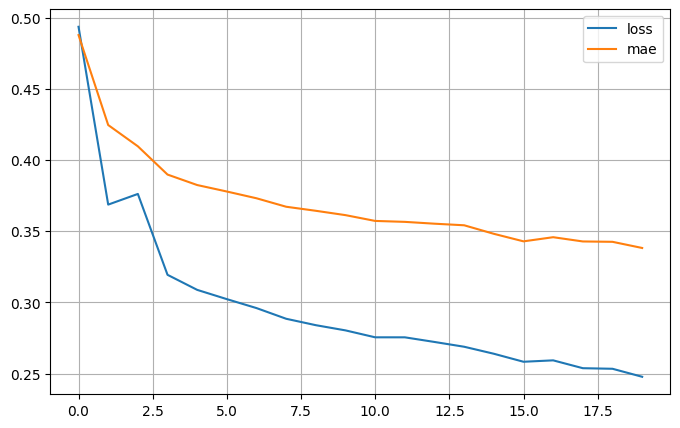

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
#plt.gca().set_ylim(0, 2) # set the vertical range to [0-1]
plt.show()

In [7]:
mse_test = final_model.evaluate(X_test_scaled, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2918 - mae: 0.3533
